## Garbage Classification
- 쓰레기 재활용 분류기 모델 + 전이학습(MobileNetV2) + 미세조정
- 데이터셋은 Google Drive에 저장된 Garbage Classification 데이터셋 읽어서 처리하기

In [1]:
from itertools import count
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

DATASET_PATH = '/content/drive/MyDrive/garbage_classification'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,           # 이미지 데이터 가져올 경로
    validation_split=0.2,   # 검증 데이터 분할
    subset='training',      # val값을 20% 가지면 나머지 traindata(80%)로 갖는다.(subset의 예약값: 'training','validation'을 구분함)
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,           # 이미지 데이터 가져올 경로
    validation_split=0.2,   # 검증 데이터 분할
    subset='validation',    # val값을 20%로 갖는다.
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 데이터셋 구조 확인하기
print(train_ds.element_spec, '\n',val_ds.element_spec)
print(len(train_ds.file_paths), len(val_ds.file_paths)) # 2022 505

class_names = train_ds.class_names
print(class_names) # ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None)) 
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
2022 505
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [2]:
# 원래 validataion dataset 을 다시 vaildataion + test dataset 으로 나누기
# train / validation / test 3개로 나누기(8:1:1)
# cardinality : batch 기준 으로 batch갯수 세기
val_batchs = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batchs // 2)
val_ds = val_ds.skip(val_batchs // 2)

# GPU 유휴시간 최소화 하기
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# 데이터 증강 ======================================================================================
# 데이터 증강 객체 생성 - concat을 진행하지 않으면 데이터 수는 늘지 않음.
data_augmentation = tf.keras.Sequential([ # 순차적으로 network를 구성하기위해 Sequential사용
    layers.RandomFlip('horizontal'),  # 좌우반전
    layers.RandomRotation(0.1),       # 이미지 회전
    layers.RandomZoom(0.1),           # 이미지 확대/축소
    layers.RandomContrast(0.1)        # 이미지 밝기/명암 조절
])

# Base Model(백본모델) 불러오기
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3, ),
    include_top=False,
    weights='imagenet'
)
# freeze
base_model.trainable = False

# 모델 생성하기(원본데이터를변형 + 전이 + 분류기)
model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3, )),
    data_augmentation,  # 갯수를 늘린것이 아니라 학습시 이미지가 입력될 때 Random하게변형이 됨.
    layers.Rescaling(1. / 127.5 , offset=-1), # [-1 ~ 1]값의 정규화
    base_model,         # 전이 학습
    layers.GlobalAveragePooling2D(),
    layers.Dropout(rate=0.3),
    layers.Dense(units=128, activation='relu'),
    layers.Dropout(rate=0.3),
    layers.Dense(len(class_names), activation='softmax')
])

print(model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [3]:
# compile / fit
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    # 학습률이 고정되면 경우에 따라 학습이 발산 또는 작아져 학습이 느려질 수 있다.
    ReduceLROnPlateau(factor=0.3, patience=2, verbose=1)
]

history_baseline = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

# 평가하기
baseline_loss, baseline_acc = model.evaluate(test_ds)
print(f'baseline_loss: {baseline_loss:.4f}, baseline_acc: {baseline_acc:.4f}') # baseline_loss: 0.5351, baseline_acc: 0.8555

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 537s 8s/step - accuracy: 0.5969 - loss: 1.0781 - val_accuracy: 0.7992 - val_loss: 0.6527 - learning_rate: 0.0010
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.7389 - loss: 0.7040 - val_accuracy: 0.8072 - val_loss: 0.5621 - learning_rate: 0.0010
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.7784 - loss: 0.5912 - val_accuracy: 0.8233 - val_loss: 0.5549 - learning_rate: 0.0010
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.8012 - loss: 0.5321 - val_accuracy: 0.7992 - val_loss: 0.6007 - learning_rate: 0.0010
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.8225 - loss: 0.4707 - val_accuracy: 0.8394 - val_loss: 0.4712 - learning_rate: 0.0010
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.8358 - loss: 0.4524 - val_accuracy: 0.8313 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 7/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8448 - loss

In [5]:
# Fine Tunning
base_model.trainable = True # BackBone Unfreeze

for layer in base_model.layers[:-30]:
  base_model.trainable = False

# Fine Tunning compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine Tunning fit
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

# 평가하기
finetune_loss, finetune_acc = model.evaluate(test_ds)
print(f'finetune_loss: {finetune_loss:.4f}, finetune_acc: {finetune_acc:.4f}') # finetune_loss: 0.4965, finetune_acc: 0.8633

# 모델 저장하기
model.save('garbage_classify.keras')

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 277ms/step - accuracy: 0.8952 - loss: 0.2987 - val_accuracy: 0.8755 - val_loss: 0.4280 - learning_rate: 1.0000e-05
Epoch 2/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8901 - loss: 0.3053
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 379ms/step - accuracy: 0.8927 - loss: 0.2979 - val_accuracy: 0.8635 - val_loss: 0.4447 - learning_rate: 1.0000e-05
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 302ms/step - accuracy: 0.8947 - loss: 0.2871 - val_accuracy: 0.8755 - val_loss: 0.4255 - learning_rate: 3.0000e-06
Epoch 4/100
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8886 - loss: 0.2911
Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.8937 - loss: 0.2858 - val_accuracy: 0.8635 - val_loss: 0.3892 - learning_rate: 3.0000e-06
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy:

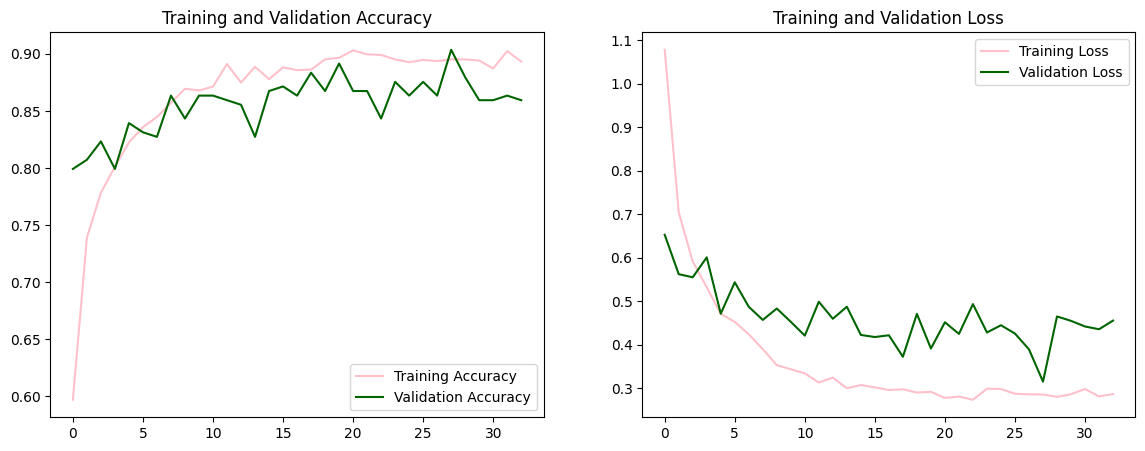

In [6]:
# acc / loss 시각화
acc = (history_baseline.history['accuracy'] + history_finetune.history['accuracy'])
val_acc = (history_baseline.history['val_accuracy'] + history_finetune.history['val_accuracy'])
loss = (history_baseline.history['loss'] + history_finetune.history['loss'])
val_loss = (history_baseline.history['val_loss'] + history_finetune.history['val_loss'])
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# acc
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='pink')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='darkgreen')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='pink')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkgreen')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


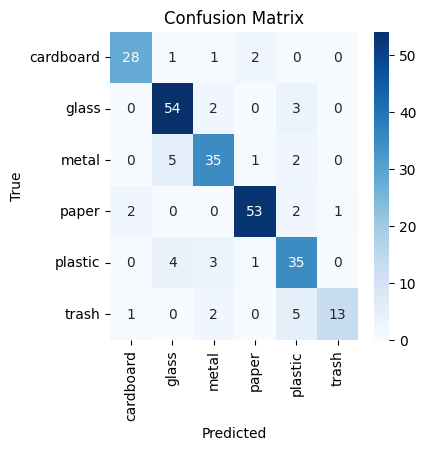

              precision    recall  f1-score   support

   cardboard       0.90      0.88      0.89        32
       glass       0.84      0.92      0.88        59
       metal       0.81      0.81      0.81        43
       paper       0.93      0.91      0.92        58
     plastic       0.74      0.81      0.78        43
       trash       0.93      0.62      0.74        21

    accuracy                           0.85       256
   macro avg       0.86      0.83      0.84       256
weighted avg       0.86      0.85      0.85       256



In [10]:
# 예측하기
y_true = []
y_pred = []

for images, labels in test_ds:
  predictions = model.predict(images)
  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
# print(cm)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [13]:
# 새로운 이미지 분류 예측하기 <- 여기서부터는 새로운 파일로 진행해야함.(새로운 파일이라 가정.)
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# 모델읽어오기
model = tf.keras.models.load_model("garbage_classify.keras")

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def predict_grabagFunc(image_path):
  img = image.load_img(image_path, target_size=(224, 224))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0) # 차원 (224, 224, 3) -> (1, 224, 224, 3)

  predictions = model.predict(img_array)
  pred_index = np.argmax(predictions)
  pred_class = class_names[pred_index]
  confidence = np.max(predictions)

  print('예측 결과 :', pred_class)
  print('신뢰도 :', round(confidence * 100, 2),'%')

  return  pred_class, confidence

predict_grabagFunc('myimage.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
예측 결과 : glass
신뢰도 : 77.38 %


('glass', np.float32(0.7738114))